### 参数的初始化

在神经网络中，**参数初始化**（Parameter Initialization）指的是在训练开始之前设置网络权重（weights）和偏置（biases）的初始值。合适的初始化策略对于神经网络的训练过程至关重要。好的初始化方法能够加速收敛，提高模型的性能，避免一些常见的问题，如梯度消失或梯度爆炸。

### 参数初始化的作用

1. **加速收敛**：
   - 一个好的初始化策略能帮助模型更快地收敛。合适的初始化会避免在训练初期陷入困境，使得梯度在反向传播时不会因为初始值太小或太大而导致学习困难。
2. **避免梯度消失和梯度爆炸**：
   - 如果初始化过小或过大，可能导致梯度在反向传播时变得非常小（梯度消失）或非常大（梯度爆炸），从而影响训练的稳定性。
   - 例如，深度网络中的梯度消失问题会导致模型训练速度极慢，甚至无法更新参数；而梯度爆炸则可能导致训练过程中权重更新过快，导致权重的值极大，进而造成不稳定的训练。
3. **确保每个神经元有不同的学习路径**：
   - 如果所有神经元的初始权重相同，那么每个神经元将执行相同的操作，导致它们在训练过程中学习到相同的特征，这会大大降低模型的表现。
   - 通过合理的初始化方法，确保每个神经元从不同的初始值开始学习，使得它们能学习到不同的特征，提高模型的多样性和表现。
4. **避免对称性破坏**：
   - 如果所有权重被初始化为相同的值，所有神经元的输出也将相同，导致网络在训练过程中无法破除对称性，使得每个神经元的更新是一样的，无法发挥出网络的深度特性。合理初始化权重能够避免这一问题。

In [ ]:
# import module
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

PyTorch 的参数初始化功能都在 `torch.nn.init` 模块下。按功能划分，主要提供了以下几类方法：

### 1. 常数初始化
将参数初始化为固定的常数或简单的矩阵结构。
*   **`nn.init.zeros_`**：初始化为全零。通常用于偏置，但不适用于权重，否则会导致神经元对称性无法打破。
*   **`nn.init.ones_`**：初始化为全一。
*   **`nn.init.constant_`**：初始化为指定的常数（如 `val=0.5`）。
*   **`nn.init.eye_`**：将二维张量初始化为单位矩阵，常用于线性层。
*   **`nn.init.dirac_`**：Dirac delta 初始化（中心为 1，其余为 0），常用于卷积层，相当于卷积的“单位初始化”。

### 2. 简单随机初始化
从基本的概率分布中采样。
*   **`nn.init.uniform_`**：从均匀分布 $ U(a, b) $ 中采样，默认 $ U(0,1) $。
*   **`nn.init.normal_`**：从正态分布 $ \mathcal{N}(\text{mean}, \text{std}) $ 中采样，默认标准正态分布。
*   **`nn.init.trunc_normal_`**：截断正态分布初始化，能避免极端值，比 `normal_` 更稳健。

### 3. 自适应初始化
这些方法会根据网络层的输入/输出维度自动调整初始化尺度，以稳定训练。
*   **Xavier 初始化**（Glorot 初始化）：
    *   **`nn.init.xavier_uniform_`**：从均匀分布采样。
    *   **`nn.init.xavier_normal_`**：从正态分布采样。
    *   **适用场景**：使用 **Sigmoid** 或 **Tanh** 激活函数的网络。
*   **Kaiming 初始化**（He 初始化）：
    *   **`nn.init.kaiming_uniform_`**：从均匀分布采样。
    *   **`nn.init.kaiming_normal_`**：从正态分布采样。
    *   **适用场景**：使用 **ReLU** 及其变体（如 Leaky ReLU）的网络，是目前 CNN 中最常用的初始化方式。
*   **正交初始化**：
    *   **`nn.init.orthogonal_`**：将矩阵初始化为（半）正交矩阵，常用于 RNN 中缓解梯度消失/爆炸。
*   **稀疏初始化**：
    *   **`nn.init.sparse_`**：将二维张量初始化为稀疏矩阵，非零元素来自正态分布。

### 4. 辅助工具
*   **`nn.init.calculate_gain`**：返回给定非线性函数（如 `relu`, `tanh`）的推荐增益值，用于配合 Xavier/Kaiming 初始化使用。

### 常用初始化方案
*   **激活函数是 ReLU**：优先选择 **Kaiming 初始化**（`kaiming_normal_` 或 `kaiming_uniform_`）。
*   **激活函数是 Sigmoid/Tanh**：选择 **Xavier 初始化**（`xavier_normal_` 或 `xavier_uniform_`）。
*   **偏置（Bias）**：通常推荐初始化为 **0**（`zeros_`），因为配合上述权重初始化已足够打破对称性。

---

#### 全0初始化

In [ ]:
def zeros_initial():
    weight = torch.empty(3,3)

    nn.init.zeros_(weight)
    print(weight)
zeros_initial()

#### 全1初始化

In [ ]:
def ones_initial():
    weight = torch.empty(3,3)

    nn.init.ones_(weight)
    print(weight)
ones_initial()

#### 常数初始化

In [ ]:
def constant_initial():
    weight = torch.empty(3,3)

    nn.init.constant_(weight,1e-3) # 0.001
    print(weight)
    print()
constant_initial()

#### 单位矩阵初始化

- 把大小为d的单位矩阵填充进**二维张量**中,其中d是这个二维张量维度的最小值即`d = argmin(tensor.shape)`

注意,该方法只适用于二维张量,因此一般是对线性层的权重进行初始化

In [ ]:
def eye_initial():
    linear = nn.Linear(5, 3)

    nn.init.eye_(linear.weight)

    print(linear.weight.data)
eye_initial()

### 狄拉克初始化
- 把一个 3/4/5 维卷积核张量初始化成 Dirac delta 函数（狄拉克δ函数），使得卷积层在初始时尽可能保持输入恒等（identity）。

In [ ]:
def dirac_initial():
    parameter = nn.Parameter(torch.empty(5,3,2))

    nn.init.dirac_(parameter.data)

    print(parameter.data)
dirac_initial()

#### 均匀分布初始化

- 从均匀分布 $ U(a, b) $ 中采样，默认 $ U(0,1) $。

In [ ]:
def uniform_initial():
    linear = nn.Linear(1000, 1000)
    # 1.从 -pi/2,pi/2采样
    a= -math.pi/2
    b= math.pi/2
    nn.init.uniform_(linear.weight,a,b)
    print(f"理论均值：E[X] = {(a + b)/2},样本均值:{linear.weight.data.mean()}")
    print(f"理论方差：Var(x) = {math.pi**2/12},样本方差:{linear.weight.data.std()}")
uniform_initial()

#### 正态初始化
- 从正态分布 $ \mathcal{N}(\text{mean}, \text{std}) $ 中采样，默认标准正态分布。

In [ ]:
def normal_initial():
    linear = nn.Linear(1000, 1000)
    # 1.从 -pi/2,pi/2采样
    mean=0.
    std=1.
    nn.init.normal_(linear.weight, mean, std)
    print(f"理论均值：E[X] = {mean},样本均值:{linear.weight.data.mean()}")
    print(f"理论方差：Var(x) = {std},样本方差:{linear.weight.data.std()}")
normal_initial()

#### 截断正态分布初始化
- 从截断的 $ \mathcal{N}(\text{mean}, \text{std}) $ 中采样,截断区间为$(a,b)$,可以有效避免极端值

- **截断正态分布**把采样范围限制在 $[a, b]$ 内，并**重新归一化**概率密度，使其积分仍为 1：
$$
f(x \mid \mu, \sigma, a, b) = \frac{\phi\!\left(\frac{x-\mu}{\sigma}\right)}{\sigma\left[\Phi\!\left(\frac{b-\mu}{\sigma}\right) - \Phi\!\left(\frac{a-\mu}{\sigma}\right)\right]}, \quad a \le x \le b
$$

- 作用
1. 避免极端值: 正态分布理论上无界。在深层网络中，偶尔出现的 $4\sigma$、$5\sigma$ 权重可能导致：
    - 激活值爆炸；
    - 梯度消失/爆炸；
    - 训练早期 loss 出现 NaN。
2. 比均匀分布更"合理"的先验: 很多场景下，我们相信权重**应该集中在 0 附近**（小权重优先），而不是均匀地散在整个区间。均匀分布给 $[-r, r]$ 内每个值同等概率，这在先验上未必合理。截断正态以 0 为中心、钟形衰减，更符合"权重应小且集中"的直觉。

In [ ]:
def truncated_normal_initial():
    linear = nn.Linear(10, 10)
    # 1.从 -pi/2,pi/2采样
    mean=0.
    std=1.
    a = -2.
    b = 2.
    nn.init.trunc_normal_(linear.weight, mean, std,a,b)
    print(f"理论均值：E[X] = {mean},样本均值:{linear.weight.data.mean()}")
    print(f"理论方差：Var(x) = {std},样本方差:{linear.weight.data.std()}")
truncated_normal_initial()

#### `kaiming`初始化/`He`初始化
He 初始化是专为 ReLU 类激活函数设计的权重初始化方法，由何恺明等人于 2015 年在论文《Delving Deep into Rectifiers》中提出。核心思想是：**根据每层的 `fan` 数自动计算初始化尺度，让信号在多层前向/反向传播中保持方差稳定。**

计算方式:
1. 计算标准差
    $$
    \text{std} = \frac{\text{gain}}{\sqrt{\text{fan\_mode}}}
    $$
    其中：
    - `gain`：激活函数增益,如激活函数为ReLU 时$\text{gain} = \sqrt{2}$
    - `fan_mode`：`fan_in`（输入维度，默认）或 `fan_out`（输出维度）
2. 采样
    - 正态分布的He初始化: 从$\mathcal{N}(0, \text{std}^2)$采样
    - 均匀分布的He初始化: 从$\mathcal{U}(-\sqrt{3}\text{std)},\sqrt{3}\text{std)})$采样

本质上,$\mathcal{N}(0, \text{std}^2)$和$\mathcal{U}(-\sqrt{3}\text{std)},\sqrt{3}\text{std)})$的期望和方差一致。
两者的区别在于：
1. 正态版本有概率产生极端值而均匀版本不会
2. 正态版本在0附近的密度更高
3. 在量化训练或低精度（FP16/BF16）场景下：
     - normal 版可能出现超出表示范围的值，需要额外裁剪；
     - uniform 版范围已知，更容易做 scale 和量化。

不过貌似大多数论文都用正态的He初始化??可能是为了更方便进行理论分析(CLT之类)??

In [ ]:
def kaiming_initial():
    linear = nn.Linear(3, 3)


    print("正态分布的He初始化:\r\n",linear.weight.data)
    print(f"样本均值:{linear.weight.data.mean()},样本方差:{linear.weight.data.std()}")
    nn.init.kaiming_uniform_(linear.weight,a= 1e-2,mode="fan_in",nonlinearity="leaky_relu")
    print("均匀分布的He初始化:\r\n",linear.weight.data)
    print(f"样本均值:{linear.weight.data.mean()},样本方差:{linear.weight.data.std()}")

kaiming_initial()

#### `xavier` 初始化
Xavier 初始化是专为 Sigmoid / Tanh 等"近似线性"激活函数设计的权重初始化方法，由 Glorot 和 Bengio 于 2010 年在论文《Understanding the difficulty of training deep feedforward neural networks》中提出。**核心目标：让信号在多层前向和反向传播中保持方差稳定，避免梯度消失或爆炸。**
`xavier` 初始化同样有两个版本:
1. 正态化的Xavier初始化
$$
w \sim \mathcal{U}(-a, a), \quad a = \text{gain} \times \sqrt{\frac{6}{n_{in} + n_{out}}}
$$
2. 均匀分布的Xavier初始化
$$
w \sim \mathcal{N}(0, \text{std}^2), \qquad \text{std} = \text{gain} \times \sqrt{\frac{2}{n_{in} + n_{out}}}
$$
其中,`fan_in` 是输入神经元的个数， `fan_out` 是输出的神经元个数,`gain` 是一个可选缩放因子,默认 1.0,用于适配不同激活函数

输入方差: 99.260704

   层           均值            标准差
   0    -0.028506       9.962967
   1     5.604614       8.258459
   2     5.950023       8.422475
   3     6.796426       9.082706
   5     6.013719       9.403888
  10     7.375751      11.349673
  20     9.859491      15.517960
  30     6.117130      11.328153
  40     7.499268      12.562861


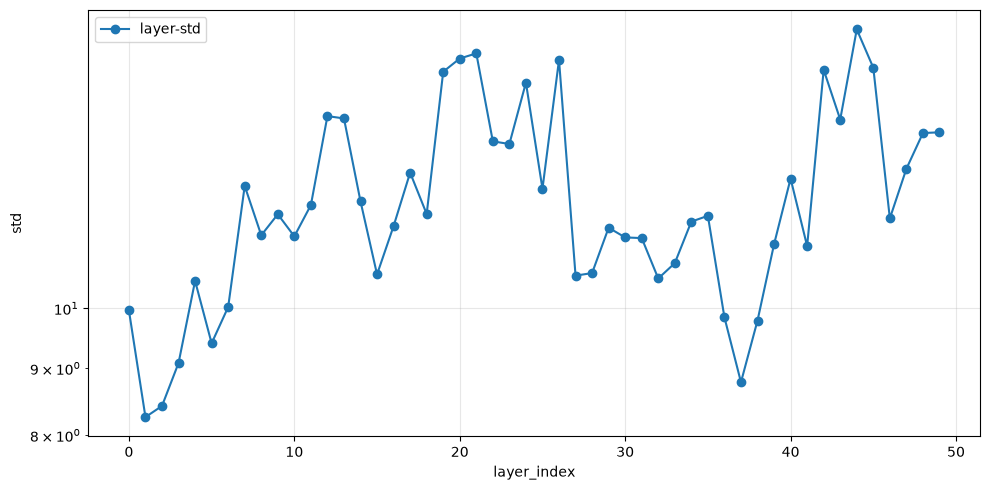

In [130]:
import torch.nn as nn

class FCNet(nn.Module):
    def __init__(self, dim=64, deep=50):
        """
        :param dim: 线性层的维度 默认是64*64
        :param deep: 网络深度
        """
        super(FCNet, self).__init__()
        self.layers = nn.ModuleList(
            nn.Linear(dim,dim,bias=False) for _ in range(deep)
        )
        self.act = nn.GELU()

        for l in self.layers:


            # nn.init.ones_(l.weight) ## 全1初始化下,很快坍缩到0
            # nn.init.uniform_(l.weight) ## 同样的问题

            # nn.init.xavier_normal_(l.weight,nn.init.calculate_gain("sigmoid"))
            # nn.init.xavier_normal_(l.weight,gain=1.5)
            # nn.init.xavier_uniform_(l.weight,gain=nn.init.calculate_gain("sigmoid"))

            # nn.init.kaiming_normal_(l.weight,a= 5e-3,mode="fan_in",nonlinearity="leaky_relu") # a: leaky_relu的负半轴系数
            nn.init.kaiming_uniform_(l.weight,a= 1e-2,mode="fan_in",nonlinearity="leaky_relu")


    def forward(self, x):
        result = []
        for i,layer in enumerate(self.layers):
            result.append({'layer_index': i ,'mean': x.mean().item(), 'std': x.std().item()})
            x = self.act(layer(x))
        return x,result

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BATCH = 1024
DIM=64
DEEP=50

data = torch.randn(BATCH, 64, device=device) * 10
print(f"输入方差: {data.var().item():.6f}\n")

model = FCNet(dim=DIM, deep=DEEP).to(device).eval()
with torch.no_grad():
    out, stats = model(data)


# ---------- 打印关键层 ----------
print(f"{'层':>4} {'均值':>12} {'标准差':>14}")
for s in stats:
    if s['layer_index'] in (0,1, 2, 3, 5, 10, 20, 30, 40, 50):
        print(f"{s['layer_index']:>4} {s['mean']:>12.6f} {s['std']:>14.6f}")

# ---------- 画图 ----------
layers = [s['layer_index'] for s in stats]
means  = [s['mean'] for s in stats]
stds   = [s['std']  for s in stats]

plt.figure(figsize=(10, 5))
plt.plot(layers, stds, 'o-', label='layer-std')

plt.xlabel('layer_index')
plt.ylabel('std')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('std.png', dpi=120)
plt.show()